# Transfer Evaluation: Negation Understanding in DistilBERT

This notebook evaluates trained probes on the JinaAI Negation Dataset to test:
1. **Transfer learning**: How well do SST-2 trained probes generalize to negation pairs?
2. **Distillation hypothesis**: Is negation understanding compressed into Layer 3?

## Prerequisites
Run this notebook **after** completing the sweep notebooks:
- `07_sweep_cls.ipynb`
- `07_sweep_mean.ipynb`
- `07_sweep_token.ipynb`

## Metrics
- **Flip Accuracy**: % of pairs where probe correctly predicts opposite sentiment for negated version
- **Prediction Confidence**: Average confidence in predictions
- **Combined Score**: 0.7 * Flip Accuracy + 0.3 * Confidence


## 1. Setup & Configuration


In [1]:
#@title **Configure Environment** { display-mode: "form" }
import os
import psutil

# Check resources
print("=" * 60)
print("ENVIRONMENT CHECK")
print("=" * 60)

# RAM check
ram_gb = psutil.virtual_memory().total / 1e9
print(f"Available RAM: {ram_gb:.1f} GB")

if ram_gb > 25:
    print("  High-RAM mode detected")
    BATCH_SIZE = 64
else:
    print("  Standard RAM mode")
    BATCH_SIZE = 32

# GPU check
import torch
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU: {gpu_name} ({gpu_mem:.1f} GB)")
    DEVICE = "cuda"
else:
    print("No GPU detected, using CPU")
    DEVICE = "cpu"
    BATCH_SIZE = 16

print(f"\nConfiguration:")
print(f"  Device: {DEVICE}")
print(f"  Batch size: {BATCH_SIZE}")
print("=" * 60)


ENVIRONMENT CHECK
Available RAM: 13.6 GB
  Standard RAM mode
GPU: Tesla T4 (15.8 GB)

Configuration:
  Device: cuda
  Batch size: 32


In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
# Clone or pull the repository
!git clone https://github.com/TheMattWang/Negation-Origin-Tracing.git 2>/dev/null || (cd Negation-Origin-Tracing && git pull)
%cd Negation-Origin-Tracing


/content/Negation-Origin-Tracing


In [4]:
# Install dependencies
%pip install -q torch lightning transformers datasets pandas pyarrow matplotlib seaborn scikit-learn tqdm scipy

# IMPORTANT: If you see a KeyError about '__reduce_cython__' after running this cell,
# you need to restart the runtime:
#   Runtime -> Restart runtime (or Ctrl+M .)
# Then re-run all cells from the beginning.

print("Dependencies installed. If this is the first run, restart the runtime now.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.9/44.9 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 846.0/846.0 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 67.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.5/849.5 kB 64.6 MB/s eta 0:00:00
Dependencies installed. If this is the first run, restart the runtime now.


In [5]:
# Set paths
import os
from datetime import datetime

DRIVE_PATH = '/content/drive/MyDrive/NOT_results'
OUTPUT_DIR = os.path.join(DRIVE_PATH, 'transfer_evaluation')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Results from sweeps: {DRIVE_PATH}")
print(f"Output directory: {OUTPUT_DIR}")


Results from sweeps: /content/drive/MyDrive/NOT_results
Output directory: /content/drive/MyDrive/NOT_results/transfer_evaluation


## 2. Check Sweep Status & Load Probes


In [6]:
import json
import glob

# Check which sweeps are complete
sweeps = {
    'cls': os.path.join(DRIVE_PATH, 'sweep_cls'),
    'mean': os.path.join(DRIVE_PATH, 'sweep_mean'),
    'token': os.path.join(DRIVE_PATH, 'sweep_token'),
}

print("Sweep Status:")
print("=" * 50)

available_probes = []

for pooling, sweep_dir in sweeps.items():
    results_file = os.path.join(sweep_dir, f'results_{pooling}.json')

    if os.path.exists(results_file):
        with open(results_file, 'r') as f:
            results = json.load(f)

        # Find checkpoints
        for result in results:
            layer = result.get('layer', result.get('layer_idx', -1))

            # Get checkpoint path from result (field is 'checkpoint' in sweep scripts)
            ckpt_path = result.get('checkpoint', result.get('checkpoint_path', ''))

            # Try to find checkpoint if path doesn't exist
            if not ckpt_path or not os.path.exists(ckpt_path):
                # Sweep script saves to: checkpoints/layer{N}_{pooling}/best*.ckpt
                ckpt_pattern = os.path.join(sweep_dir, 'checkpoints', f'layer{layer}_{pooling}', 'best*.ckpt')
                ckpt_matches = glob.glob(ckpt_pattern)
                if ckpt_matches:
                    ckpt_path = ckpt_matches[0]
                else:
                    # Also try alternative pattern
                    ckpt_pattern2 = os.path.join(sweep_dir, f'layer_{layer}_pooling_{pooling}', 'checkpoints', 'best*.ckpt')
                    ckpt_matches2 = glob.glob(ckpt_pattern2)
                    if ckpt_matches2:
                        ckpt_path = ckpt_matches2[0]

            if ckpt_path and os.path.exists(ckpt_path):
                available_probes.append({
                    'layer': layer,
                    'pooling': pooling,
                    'checkpoint': ckpt_path,
                    'val_acc': result.get('test_acc', result.get('test_accuracy', result.get('val_accuracy', 0))),
                })

        print(f"  {pooling.upper()}: {len(results)} experiments found")
    else:
        print(f"  {pooling.upper()}: Not found")

print(f"\nTotal probes with checkpoints: {len(available_probes)}")

if len(available_probes) == 0:
    print("\n WARNING: No probe checkpoints found!")
    print("Please run the sweep notebooks first (07_sweep_*.ipynb)")
    print("\nDebug: Checking sweep directories...")
    for pooling, sweep_dir in sweeps.items():
        print(f"  {pooling}: {sweep_dir}")
        if os.path.exists(sweep_dir):
            print(f"    Contents: {os.listdir(sweep_dir)[:5]}...")
        else:
            print(f"    Directory does not exist")


Sweep Status:
  CLS: 6 experiments found
  MEAN: 6 experiments found
  TOKEN: 6 experiments found

Total probes with checkpoints: 18


In [7]:
# Display available probes
import pandas as pd

if available_probes:
    probes_df = pd.DataFrame(available_probes)
    print("Available Probes:")
    print(probes_df[['layer', 'pooling', 'val_acc']].to_string(index=False))


Available Probes:
 layer pooling  val_acc
     0     cls 0.748853
     1     cls 0.740826
     2     cls 0.769495
     3     cls 0.797018
     4     cls 0.815367
     5     cls 0.846330
     0    mean 0.797018
     1    mean 0.807339
     2    mean 0.808486
     3    mean 0.839450
     4    mean 0.847477
     5    mean 0.844037
     0   token 0.737385
     1   token 0.748853
     2   token 0.770642
     3   token 0.797018
     4   token 0.817661
     5   token 0.844037


## 3. Download Negation Dataset


In [8]:
# Download JinaAI Negation Dataset
NEGATION_DATA_DIR = 'data/raw/negation'

if not os.path.exists(os.path.join(NEGATION_DATA_DIR, 'test.parquet')):
    print("Downloading JinaAI Negation Dataset...")
    !python src/data/download_negation.py --output_dir {NEGATION_DATA_DIR}
else:
    print("Negation dataset already exists!")

# Show dataset info
for split in ['train', 'test']:
    path = os.path.join(NEGATION_DATA_DIR, f'{split}.parquet')
    if os.path.exists(path):
        df = pd.read_parquet(path)
        print(f"  {split}: {len(df)} examples")


README.md: 3.75kB [00:00, 1.69MB/s]
negation-dataset-v2.py: 4.54kB [00:00, 1.33MB/s]
Error downloading dataset: Dataset scripts are no longer supported, but found negation-dataset-v2.py

Trying alternative approach...
Trying jinaai/negation-dataset...
README.md: 3.99kB [00:00, 15.9MB/s]
negation_training.tsv: 1.39MB [00:00, 26.9MB/s]
negation_evaluation.tsv: 73.7kB [00:00, 5.82MB/s]
Generating train split: 100% 10000/10000 [00:00<00:00, 73173.48 examples/s]
Generating test split: 100% 500/500 [00:00<00:00, 26692.19 examples/s]
Creating parquet from Arrow format: 100% 10/10 [00:00<00:00, 161.45ba/s]
  Saved train: 10000 examples -> /content/Negation-Origin-Tracing/data/raw/negation/train.parquet
Creating parquet from Arrow format: 100% 1/1 [00:00<00:00, 749.65ba/s]
  Saved test: 500 examples -> /content/Negation-Origin-Tracing/data/raw/negation/test.parquet

✓ Download complete!
  train: 10000 examples
  test: 500 examples


## 4. Load Model and Evaluation Setup


In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoModel, AutoTokenizer
from tqdm.auto import tqdm
import numpy as np

# Load base model
MODEL_NAME = "distilbert-base-uncased"
print(f"Loading {MODEL_NAME}...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
base_model = AutoModel.from_pretrained(MODEL_NAME)
base_model = base_model.to(DEVICE)
base_model.eval()

print(f"Model loaded on {DEVICE}")
print(f"Hidden size: {base_model.config.hidden_size}")
print(f"Num layers: {base_model.config.num_hidden_layers}")


Loading distilbert-base-uncased...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Model loaded on cuda
Hidden size: 768
Num layers: 6


In [10]:
# Define probe loading function
import sys
sys.path.insert(0, '.')

from src.models import BaseModule

def load_probe_from_checkpoint(checkpoint_path, layer_idx, pooling_strategy):
    """
    Load a trained probe from checkpoint.
    Returns the linear probe layer.
    """
    # Load the full model from checkpoint
    model = BaseModule.load_from_checkpoint(
        checkpoint_path,
        model_name=MODEL_NAME,
        mode="probe",
        probe_layer=layer_idx,
        pooling_strategy=pooling_strategy,
    )
    model = model.to(DEVICE)
    model.eval()

    # Extract just the probe (linear layer)
    probe = model.probes[f"layer_{layer_idx}"]

    return model, probe

print("Probe loading function defined.")


Probe loading function defined.


In [11]:
# Load negation dataset
from src.datasets.dataset import NegationTripletDataset
from torch.utils.data import DataLoader

# Use test split for evaluation
test_path = os.path.join(NEGATION_DATA_DIR, 'test.parquet')
if not os.path.exists(test_path):
    # Fall back to train if test doesn't exist
    test_path = os.path.join(NEGATION_DATA_DIR, 'train.parquet')
    print("Using train split (test not found)")

negation_dataset = NegationTripletDataset(
    data_path=test_path,
    tokenizer=tokenizer,
    max_length=128,
)

negation_loader = DataLoader(
    negation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
)

print(f"\nLoaded {len(negation_dataset)} negation pairs")


[NegationTripletDataset] Loaded 500 pairs from test.parquet
  Sample anchor: This church choir sings to the masses as they sing joyous so...
  Sample negative: The church is empty of song....

Loaded 500 negation pairs


## 5. Evaluation Functions


In [12]:
def extract_features(model, input_ids, attention_mask, layer_idx, pooling_strategy):
    """
    Extract features from a specific layer using the specified pooling strategy.
    """
    with torch.no_grad():
        outputs = model.backbone(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_hidden_states=True,
        )

        # Get hidden states for the specified layer
        # hidden_states[0] is embeddings, hidden_states[1] is layer 0, etc.
        hidden_states = outputs.hidden_states[layer_idx + 1]

        # Apply pooling
        if pooling_strategy == "cls":
            features = hidden_states[:, 0, :]
        elif pooling_strategy == "mean":
            mask_expanded = attention_mask.unsqueeze(-1).expand(hidden_states.size()).float()
            sum_hidden = torch.sum(hidden_states * mask_expanded, dim=1)
            sum_mask = torch.clamp(mask_expanded.sum(dim=1), min=1e-9)
            features = sum_hidden / sum_mask
        elif pooling_strategy == "token":
            # Pool around "not" token
            not_token_id = tokenizer.convert_tokens_to_ids("not")
            batch_size = hidden_states.size(0)
            pooled = []

            for i in range(batch_size):
                not_positions = (input_ids[i] == not_token_id).nonzero(as_tuple=True)[0]

                if len(not_positions) > 0:
                    not_idx = not_positions[0].item()
                    start_idx = max(0, not_idx - 1)
                    end_idx = min(hidden_states.size(1), not_idx + 2)
                    valid_mask = attention_mask[i, start_idx:end_idx].bool()
                    if valid_mask.any():
                        pooled_hidden = hidden_states[i, start_idx:end_idx, :][valid_mask].mean(dim=0)
                    else:
                        pooled_hidden = hidden_states[i, not_idx, :]
                else:
                    pooled_hidden = hidden_states[i, 0, :]

                pooled.append(pooled_hidden)

            features = torch.stack(pooled)
        else:
            raise ValueError(f"Unknown pooling strategy: {pooling_strategy}")

        return features


def evaluate_probe_on_negation(model, probe, negation_loader, layer_idx, pooling_strategy):
    """
    Evaluate a probe on the negation dataset.

    Returns:
        dict with flip_accuracy, avg_confidence, and other metrics
    """
    model.eval()
    probe.eval()

    total_pairs = 0
    correct_flips = 0
    anchor_confidences = []
    negative_confidences = []

    with torch.no_grad():
        for batch in tqdm(negation_loader, desc=f"Layer {layer_idx}, {pooling_strategy}", leave=False):
            # Move to device
            anchor_ids = batch['anchor_input_ids'].to(DEVICE)
            anchor_mask = batch['anchor_attention_mask'].to(DEVICE)
            negative_ids = batch['negative_input_ids'].to(DEVICE)
            negative_mask = batch['negative_attention_mask'].to(DEVICE)

            # Extract features
            anchor_features = extract_features(
                model, anchor_ids, anchor_mask, layer_idx, pooling_strategy
            )
            negative_features = extract_features(
                model, negative_ids, negative_mask, layer_idx, pooling_strategy
            )

            # Get predictions
            anchor_logits = probe(anchor_features)
            negative_logits = probe(negative_features)

            # Get predicted classes
            anchor_preds = torch.argmax(anchor_logits, dim=-1)
            negative_preds = torch.argmax(negative_logits, dim=-1)

            # Get confidences (probability of predicted class)
            anchor_probs = F.softmax(anchor_logits, dim=-1)
            negative_probs = F.softmax(negative_logits, dim=-1)

            anchor_conf = anchor_probs.max(dim=-1).values
            negative_conf = negative_probs.max(dim=-1).values

            # Count flips (predictions should differ for anchor vs negative)
            flips = (anchor_preds != negative_preds).sum().item()
            correct_flips += flips
            total_pairs += len(anchor_ids)

            anchor_confidences.extend(anchor_conf.cpu().numpy())
            negative_confidences.extend(negative_conf.cpu().numpy())

    flip_accuracy = correct_flips / total_pairs if total_pairs > 0 else 0
    avg_anchor_conf = float(np.mean(anchor_confidences))
    avg_negative_conf = float(np.mean(negative_confidences))
    avg_confidence = (avg_anchor_conf + avg_negative_conf) / 2

    # Combined score (weighted)
    combined_score = 0.7 * flip_accuracy + 0.3 * avg_confidence

    # Convert all values to Python native types for JSON serialization
    return {
        'layer': int(layer_idx),
        'pooling': pooling_strategy,
        'flip_accuracy': float(flip_accuracy),
        'avg_confidence': float(avg_confidence),
        'avg_anchor_confidence': float(avg_anchor_conf),
        'avg_negative_confidence': float(avg_negative_conf),
        'combined_score': float(combined_score),
        'total_pairs': int(total_pairs),
        'correct_flips': int(correct_flips),
    }

print("Evaluation functions defined.")


Evaluation functions defined.


## 6. Run Transfer Evaluation


In [13]:
import time
from datetime import datetime, timedelta

# Run evaluation on all available probes
print("=" * 60)
print("TRANSFER EVALUATION")
print("=" * 60)
print(f"Evaluating {len(available_probes)} probes on {len(negation_dataset)} negation pairs")
print(f"Started at: {datetime.now().strftime('%H:%M:%S')}")
print("=" * 60)

all_results = []
start_time = time.time()

for i, probe_info in enumerate(available_probes):
    layer = probe_info['layer']
    pooling = probe_info['pooling']
    checkpoint = probe_info['checkpoint']

    print(f"\n[{i+1}/{len(available_probes)}] Layer {layer}, {pooling.upper()} pooling")

    try:
        # Load probe
        model, probe = load_probe_from_checkpoint(checkpoint, layer, pooling)

        # Evaluate
        result = evaluate_probe_on_negation(
            model, probe, negation_loader, layer, pooling
        )

        # Add original validation accuracy
        result['val_accuracy'] = probe_info['val_acc']
        result['checkpoint'] = checkpoint

        all_results.append(result)

        print(f"    Flip Accuracy: {result['flip_accuracy']:.3f}")
        print(f"    Avg Confidence: {result['avg_confidence']:.3f}")
        print(f"    Combined Score: {result['combined_score']:.3f}")

        # Estimate remaining time
        elapsed = time.time() - start_time
        avg_time = elapsed / (i + 1)
        remaining = avg_time * (len(available_probes) - i - 1)
        print(f"    ETA: {timedelta(seconds=int(remaining))}")

        # Save intermediate results
        with open(os.path.join(OUTPUT_DIR, 'results.json'), 'w') as f:
            json.dump(all_results, f, indent=2)

        # Clear GPU cache
        if DEVICE == "cuda":
            del model, probe
            torch.cuda.empty_cache()

    except Exception as e:
        print(f"    ERROR: {e}")
        all_results.append({
            'layer': layer,
            'pooling': pooling,
            'error': str(e),
        })

print("\n" + "=" * 60)
print("EVALUATION COMPLETE")
print(f"Total time: {timedelta(seconds=int(time.time() - start_time))}")
print("=" * 60)


TRANSFER EVALUATION
Evaluating 18 probes on 500 negation pairs
Started at: 06:57:37

[1/18] Layer 0, CLS pooling


Layer 0, cls:   0%|          | 0/16 [00:00<?, ?it/s]

    Flip Accuracy: 0.404
    Avg Confidence: 0.634
    Combined Score: 0.473
    ETA: 0:04:56

[2/18] Layer 1, CLS pooling


Layer 1, cls:   0%|          | 0/16 [00:00<?, ?it/s]

    Flip Accuracy: 0.334
    Avg Confidence: 0.675
    Combined Score: 0.436
    ETA: 0:03:35

[3/18] Layer 2, CLS pooling


...

Layer 4, token:   0%|          | 0/16 [00:00<?, ?it/s]

Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f0694b1de40><function _MultiProcessingDataLoaderIter.__del__ at 0x7f0694b1de40>
Traceback (most recent call last):

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
Traceback (most recent call last):
      File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
self._shutdown_workers()    
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
self._shutdown_workers()
      File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
if w.is_alive():    
if w.is_alive(): 
             ^^^^^^^^^^^^^^^^^^^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive

      File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
assert self._par

    Flip Accuracy: 0.354
    Avg Confidence: 0.819
    Combined Score: 0.493
    ETA: 0:00:22

[18/18] Layer 5, TOKEN pooling


Layer 5, token:   0%|          | 0/16 [00:00<?, ?it/s]

    Flip Accuracy: 0.236
    Avg Confidence: 0.852
    Combined Score: 0.421
    ETA: 0:00:00

EVALUATION COMPLETE
Total time: 0:06:34


In [14]:
# Display results summary
results_df = pd.DataFrame([r for r in all_results if 'error' not in r])

if len(results_df) > 0:
    print("\nRESULTS SUMMARY")
    print("=" * 60)

    # Sort by combined score
    results_df = results_df.sort_values('combined_score', ascending=False)

    print(results_df[['layer', 'pooling', 'flip_accuracy', 'avg_confidence', 'combined_score', 'val_accuracy']].to_string(index=False))

    # Best configuration
    best = results_df.iloc[0]
    print(f"\nBEST CONFIGURATION:")
    print(f"  Layer {int(best['layer'])}, {best['pooling'].upper()} pooling")
    print(f"  Flip Accuracy: {best['flip_accuracy']:.3f}")
    print(f"  Combined Score: {best['combined_score']:.3f}")



RESULTS SUMMARY
 layer pooling  flip_accuracy  avg_confidence  combined_score  val_accuracy
     3    mean          0.422        0.791149        0.532745      0.839450
     0   token          0.434        0.676082        0.506625      0.737385
     4     cls          0.372        0.810594        0.503578      0.815367
     4    mean          0.380        0.783857        0.501157      0.847477
     0    mean          0.378        0.770525        0.495758      0.797018
     4   token          0.354        0.818793        0.493438      0.817661
     5    mean          0.352        0.806854        0.488456      0.844037
     2   token          0.380        0.740631        0.488189      0.770642
     1    mean          0.352        0.790593        0.483578      0.807339
     2    mean          0.334        0.798914        0.473474      0.808486
     0     cls          0.404        0.633938        0.472981      0.748853
     1   token          0.348        0.723016        0.460505      0.74

## 7. Hypothesis Testing: Layer 3 Distillation


In [15]:
from scipy import stats

print("=" * 60)
print("HYPOTHESIS TEST: Layer 3 Distillation")
print("=" * 60)
print("\nHypothesis: Negation understanding is compressed into Layer 3")
print("           (corresponding to BERT layers 7/9)")

if len(results_df) > 0:
    # Get Layer 3 scores vs other layers
    layer_3_scores = results_df[results_df['layer'] == 3]['combined_score'].values
    other_scores = results_df[results_df['layer'] != 3]['combined_score'].values

    print(f"\nLayer 3 scores: {layer_3_scores}")
    print(f"Other layers mean: {other_scores.mean():.3f}")

    if len(layer_3_scores) > 0 and len(other_scores) > 1:
        # T-test
        t_stat, p_value = stats.ttest_ind(layer_3_scores, other_scores)

        # Effect size (Cohen's d)
        pooled_std = np.sqrt(((len(layer_3_scores)-1)*np.var(layer_3_scores) +
                              (len(other_scores)-1)*np.var(other_scores)) /
                             (len(layer_3_scores) + len(other_scores) - 2))
        cohens_d = (np.mean(layer_3_scores) - np.mean(other_scores)) / pooled_std if pooled_std > 0 else 0

        print(f"\nStatistical Analysis:")
        print(f"  Layer 3 mean: {np.mean(layer_3_scores):.3f}")
        print(f"  Other layers mean: {np.mean(other_scores):.3f}")
        print(f"  t-statistic: {t_stat:.3f}")
        print(f"  p-value: {p_value:.4f}")
        print(f"  Cohen's d: {cohens_d:.3f}")

        if p_value < 0.05 and np.mean(layer_3_scores) > np.mean(other_scores):
            print(f"\n  HYPOTHESIS SUPPORTED (p < 0.05)")
            print(f"  Layer 3 shows significantly better negation understanding.")
        elif p_value < 0.05:
            print(f"\n  HYPOTHESIS NOT SUPPORTED")
            print(f"  Layer 3 performs significantly WORSE than other layers.")
        else:
            print(f"\n  NO SIGNIFICANT DIFFERENCE (p >= 0.05)")
            print(f"  Cannot confirm Layer 3 has special negation understanding.")

    # Layer-by-layer analysis
    print("\nPerformance by Layer:")
    layer_stats = results_df.groupby('layer').agg({
        'flip_accuracy': 'mean',
        'combined_score': 'mean',
    }).round(3)
    print(layer_stats)

    # Best layer
    best_layer = layer_stats['combined_score'].idxmax()
    print(f"\nBest performing layer: {best_layer}")


HYPOTHESIS TEST: Layer 3 Distillation

Hypothesis: Negation understanding is compressed into Layer 3
           (corresponding to BERT layers 7/9)

Layer 3 scores: [0.53274473 0.40513433 0.39486103]
Other layers mean: 0.474

Statistical Analysis:
  Layer 3 mean: 0.444
  Other layers mean: 0.474
  t-statistic: -1.287
  p-value: 0.2165
  Cohen's d: -0.916

  NO SIGNIFICANT DIFFERENCE (p >= 0.05)
  Cannot confirm Layer 3 has special negation understanding.

Performance by Layer:
       flip_accuracy  combined_score
layer                               
0              0.405           0.492
1              0.345           0.460
2              0.341           0.468
3              0.292           0.444
4              0.369           0.499
5              0.291           0.452

Best performing layer: 4


## 8. Visualizations


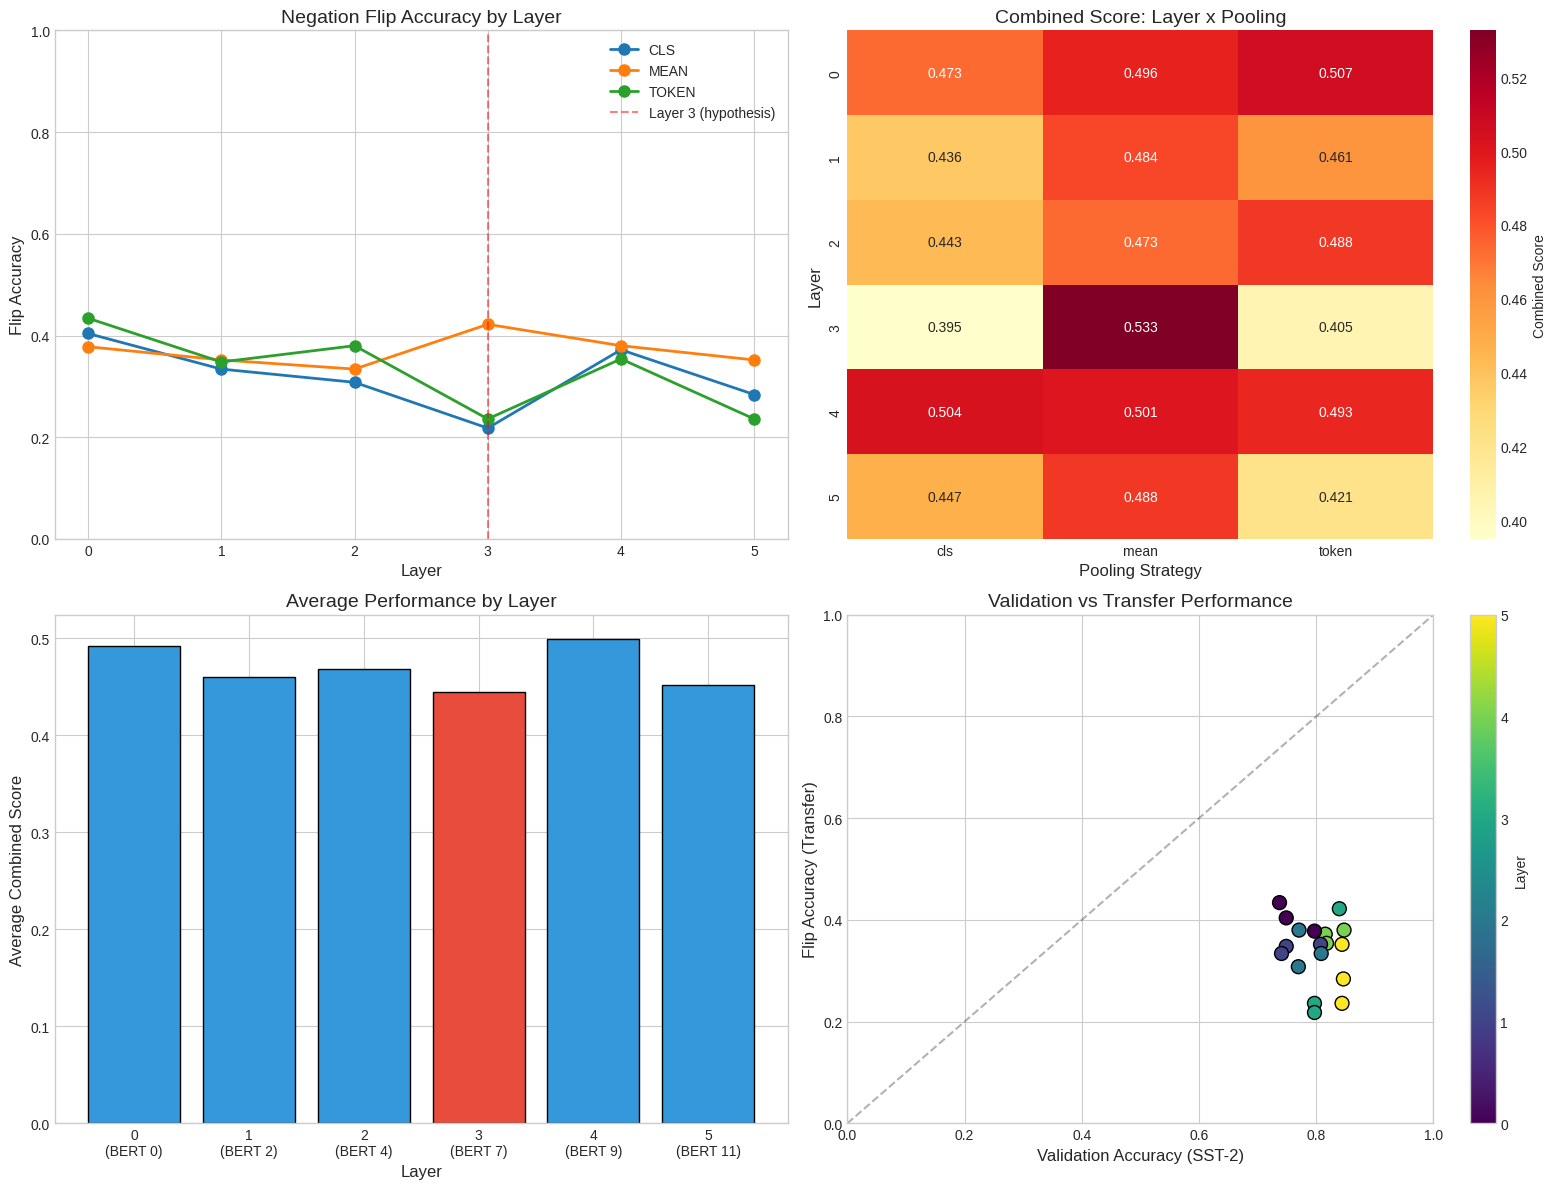


Plot saved to: /content/drive/MyDrive/NOT_results/transfer_evaluation/transfer_evaluation.png


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(16, 12))

# BERT layer mapping for DistilBERT
bert_mapping = {0: 0, 1: 2, 2: 4, 3: 7, 4: 9, 5: 11}

if len(results_df) > 0:
    # Plot 1: Flip Accuracy by Layer (lines for each pooling)
    ax1 = plt.subplot(2, 2, 1)
    for pooling in ['cls', 'mean', 'token']:
        pool_data = results_df[results_df['pooling'] == pooling].sort_values('layer')
        if len(pool_data) > 0:
            ax1.plot(pool_data['layer'], pool_data['flip_accuracy'],
                    marker='o', label=pooling.upper(), linewidth=2, markersize=8)

    ax1.axvline(x=3, color='red', linestyle='--', alpha=0.5, label='Layer 3 (hypothesis)')
    ax1.set_xlabel('Layer', fontsize=12)
    ax1.set_ylabel('Flip Accuracy', fontsize=12)
    ax1.set_title('Negation Flip Accuracy by Layer', fontsize=14)
    ax1.legend()
    ax1.set_xticks(range(6))
    ax1.set_ylim(0, 1)

    # Plot 2: Heatmap of Combined Scores
    ax2 = plt.subplot(2, 2, 2)
    pivot_data = results_df.pivot(index='layer', columns='pooling', values='combined_score')
    sns.heatmap(pivot_data, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax2,
                cbar_kws={'label': 'Combined Score'})
    ax2.set_title('Combined Score: Layer x Pooling', fontsize=14)
    ax2.set_xlabel('Pooling Strategy', fontsize=12)
    ax2.set_ylabel('Layer', fontsize=12)

    # Plot 3: Layer Comparison Bar Chart
    ax3 = plt.subplot(2, 2, 3)
    layer_means = results_df.groupby('layer')['combined_score'].mean().sort_index()
    colors = ['#3498db'] * 6
    if 3 in layer_means.index:
        colors[3] = '#e74c3c'  # Highlight layer 3
    bars = ax3.bar(layer_means.index, layer_means.values, color=colors, edgecolor='black')
    ax3.set_xlabel('Layer', fontsize=12)
    ax3.set_ylabel('Average Combined Score', fontsize=12)
    ax3.set_title('Average Performance by Layer', fontsize=14)
    ax3.set_xticks(range(6))
    ax3.set_xticklabels([f'{i}\n(BERT {bert_mapping[i]})' for i in range(6)])

    # Plot 4: Validation vs Transfer Performance
    ax4 = plt.subplot(2, 2, 4)
    scatter = ax4.scatter(results_df['val_accuracy'], results_df['flip_accuracy'],
               c=results_df['layer'], cmap='viridis', s=100, edgecolors='black')
    ax4.set_xlabel('Validation Accuracy (SST-2)', fontsize=12)
    ax4.set_ylabel('Flip Accuracy (Transfer)', fontsize=12)
    ax4.set_title('Validation vs Transfer Performance', fontsize=14)
    cbar = plt.colorbar(scatter, ax=ax4)
    cbar.set_label('Layer')
    lims = [0, 1]
    ax4.plot(lims, lims, 'k--', alpha=0.3, label='y=x')
    ax4.set_xlim(lims)
    ax4.set_ylim(lims)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'transfer_evaluation.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\nPlot saved to: {os.path.join(OUTPUT_DIR, 'transfer_evaluation.png')}")


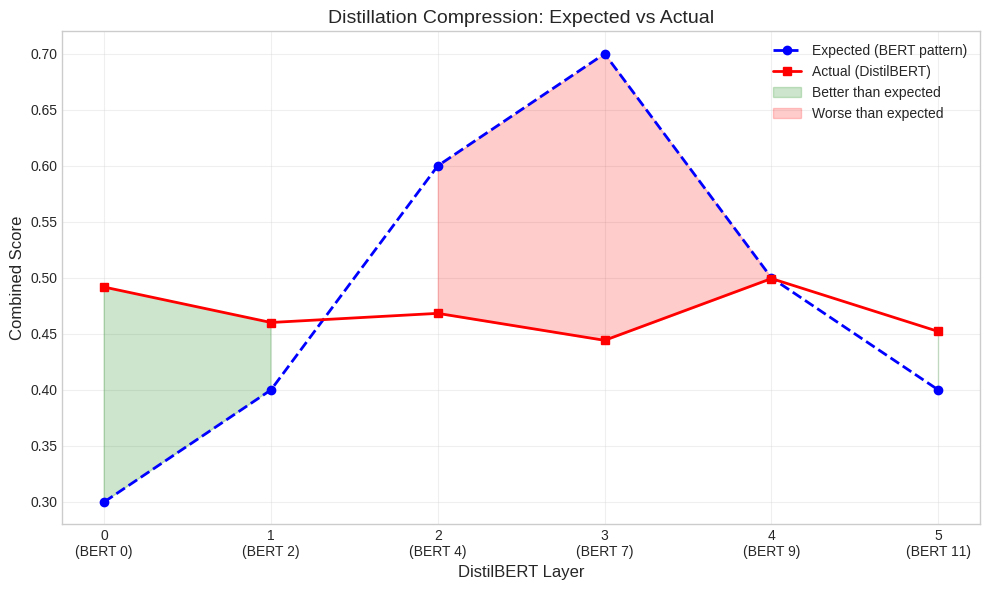

Plot saved to: /content/drive/MyDrive/NOT_results/transfer_evaluation/distillation_pattern.png


In [17]:
# Additional visualization: Distillation Pattern
if len(results_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))

    # Expected pattern based on BERT literature
    # Negation peaks around layers 7-9 in BERT-base
    # In DistilBERT (6 layers), this maps to layers 2-4
    expected_pattern = [0.3, 0.4, 0.6, 0.7, 0.5, 0.4]  # Rough expected curve

    # Actual pattern
    actual_pattern = results_df.groupby('layer')['combined_score'].mean().sort_index().values

    # Pad if not all layers present
    if len(actual_pattern) < 6:
        full_pattern = [0.0] * 6
        for idx, layer in enumerate(results_df.groupby('layer')['combined_score'].mean().sort_index().index):
            full_pattern[int(layer)] = actual_pattern[idx]
        actual_pattern = full_pattern

    layers = range(6)
    ax.plot(layers, expected_pattern, 'b--', marker='o', label='Expected (BERT pattern)', linewidth=2)
    ax.plot(layers, actual_pattern, 'r-', marker='s', label='Actual (DistilBERT)', linewidth=2)

    # Fill between
    ax.fill_between(layers, expected_pattern, actual_pattern,
                   where=[a > e for a, e in zip(actual_pattern, expected_pattern)],
                   color='green', alpha=0.2, label='Better than expected')
    ax.fill_between(layers, expected_pattern, actual_pattern,
                   where=[a < e for a, e in zip(actual_pattern, expected_pattern)],
                   color='red', alpha=0.2, label='Worse than expected')

    ax.set_xlabel('DistilBERT Layer', fontsize=12)
    ax.set_ylabel('Combined Score', fontsize=12)
    ax.set_title('Distillation Compression: Expected vs Actual', fontsize=14)
    ax.legend()
    ax.set_xticks(range(6))
    ax.set_xticklabels([f'{i}\n(BERT {bert_mapping[i]})' for i in range(6)])
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'distillation_pattern.png'), dpi=150, bbox_inches='tight')
    plt.show()

    print(f"Plot saved to: {os.path.join(OUTPUT_DIR, 'distillation_pattern.png')}")


## 9. Generate Report


In [18]:
# Generate markdown report
report = f"""# Transfer Evaluation Report

Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

## Overview

- **Dataset**: JinaAI Negation Dataset
- **Test pairs**: {len(negation_dataset)}
- **Probes evaluated**: {len(available_probes)}
- **Model**: DistilBERT (distilbert-base-uncased)

## Results Summary

"""

if len(results_df) > 0:
    # Best configuration
    best = results_df.iloc[0]
    report += f"""### Best Configuration

| Metric | Value |
|--------|-------|
| Layer | {int(best['layer'])} |
| Pooling | {best['pooling'].upper()} |
| Flip Accuracy | {best['flip_accuracy']:.3f} |
| Combined Score | {best['combined_score']:.3f} |

### All Results

| Layer | Pooling | Flip Acc | Confidence | Combined | Val Acc |
|-------|---------|----------|------------|----------|----------|
"""

    for _, row in results_df.iterrows():
        report += f"| {int(row['layer'])} | {row['pooling'].upper()} | {row['flip_accuracy']:.3f} | {row['avg_confidence']:.3f} | {row['combined_score']:.3f} | {row['val_accuracy']:.3f} |\n"

    # Hypothesis test results
    layer_3_scores = results_df[results_df['layer'] == 3]['combined_score'].values
    other_scores = results_df[results_df['layer'] != 3]['combined_score'].values

    if len(layer_3_scores) > 0 and len(other_scores) > 1:
        t_stat, p_value = stats.ttest_ind(layer_3_scores, other_scores)

        report += f"""
## Hypothesis Test: Layer 3 Distillation

**Hypothesis**: Negation understanding is compressed into Layer 3 in DistilBERT
(corresponding to BERT layers 7/9).

| Metric | Value |
|--------|-------|
| Layer 3 mean score | {np.mean(layer_3_scores):.3f} |
| Other layers mean | {np.mean(other_scores):.3f} |
| t-statistic | {t_stat:.3f} |
| p-value | {p_value:.4f} |

**Conclusion**: """

        if p_value < 0.05 and np.mean(layer_3_scores) > np.mean(other_scores):
            report += "Hypothesis SUPPORTED. Layer 3 shows significantly better negation understanding.\n"
        elif p_value < 0.05:
            report += "Hypothesis NOT SUPPORTED. Layer 3 performs significantly worse than other layers.\n"
        else:
            report += "NO SIGNIFICANT DIFFERENCE. Cannot confirm Layer 3 has special negation understanding.\n"

report += f"""
## Visualizations

- `transfer_evaluation.png`: Main evaluation plots
- `distillation_pattern.png`: Expected vs actual distillation pattern

## Files

- `results.json`: Raw evaluation results
- `TRANSFER_REPORT.md`: This report
"""

# Save report
report_path = os.path.join(OUTPUT_DIR, 'TRANSFER_REPORT.md')
with open(report_path, 'w') as f:
    f.write(report)

print(f"Report saved to: {report_path}")
print("\n" + "=" * 60)
print(report)


Report saved to: /content/drive/MyDrive/NOT_results/transfer_evaluation/TRANSFER_REPORT.md

# Transfer Evaluation Report

Generated: 2025-12-03 07:04:24

## Overview

- **Dataset**: JinaAI Negation Dataset
- **Test pairs**: 500
- **Probes evaluated**: 18
- **Model**: DistilBERT (distilbert-base-uncased)

## Results Summary

### Best Configuration

| Metric | Value |
|--------|-------|
| Layer | 3 |
| Pooling | MEAN |
| Flip Accuracy | 0.422 |
| Combined Score | 0.533 |

### All Results

| Layer | Pooling | Flip Acc | Confidence | Combined | Val Acc |
|-------|---------|----------|------------|----------|----------|
| 3 | MEAN | 0.422 | 0.791 | 0.533 | 0.839 |
| 0 | TOKEN | 0.434 | 0.676 | 0.507 | 0.737 |
| 4 | CLS | 0.372 | 0.811 | 0.504 | 0.815 |
| 4 | MEAN | 0.380 | 0.784 | 0.501 | 0.847 |
| 0 | MEAN | 0.378 | 0.771 | 0.496 | 0.797 |
| 4 | TOKEN | 0.354 | 0.819 | 0.493 | 0.818 |
| 5 | MEAN | 0.352 | 0.807 | 0.488 | 0.844 |
| 2 | TOKEN | 0.380 | 0.741 | 0.488 | 0.771 |
| 1 | MEAN | 0.

In [19]:
# Save final results
with open(os.path.join(OUTPUT_DIR, 'results.json'), 'w') as f:
    json.dump(all_results, f, indent=2)

print(f"\nAll results saved to: {OUTPUT_DIR}")
print("\nFiles:")
for f in os.listdir(OUTPUT_DIR):
    print(f"  - {f}")



All results saved to: /content/drive/MyDrive/NOT_results/transfer_evaluation

Files:
  - results.json
  - transfer_evaluation.png
  - distillation_pattern.png
  - TRANSFER_REPORT.md


## 10. Summary

This notebook evaluated trained probes on the JinaAI Negation Dataset to test transfer learning and the distillation hypothesis. Check the TRANSFER_REPORT.md file in the output directory for detailed results.


Testing Bert and DistilledBert

In [21]:
print("Type:", type(negation_loader))
print("\nFirst batch:")
batch = next(iter(negation_loader))
print(batch)

# If it's a tensor or list, show shapes
if isinstance(batch, torch.Tensor):
    print("Shape:", batch.shape)
elif isinstance(batch, (list, tuple)):
    print("Length:", len(batch))
    for i, item in enumerate(batch):
        if hasattr(item, 'shape'):
            print(f"  Item {i}: shape {item.shape}")
        else:
            print(f"  Item {i}: type {type(item)}, length {len(item) if hasattr(item, '__len__') else 'N/A'}")
elif isinstance(batch, dict):
    for key, value in batch.items():
        if hasattr(value, 'shape'):
            print(f"  {key}: shape {value.shape}")
        else:
            print(f"  {key}: type {type(value)}, length {len(value) if hasattr(value, '__len__') else 'N/A'}")

Type: <class 'torch.utils.data.dataloader.DataLoader'>

First batch:
{'anchor_input_ids': tensor([[ 101, 2023, 2277,  ...,    0,    0,    0],
        [ 101, 1037, 2450,  ...,    0,    0,    0],
        [ 101, 1037, 6231,  ...,    0,    0,    0],
        ...,
        [ 101, 2111, 2024,  ...,    0,    0,    0],
        [ 101, 1037, 2611,  ...,    0,    0,    0],
        [ 101, 1037, 2450,  ...,    0,    0,    0]]), 'anchor_attention_mask': tensor([[1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        ...,
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0]]), 'negative_input_ids': tensor([[ 101, 1996, 2277,  ...,    0,    0,    0],
        [ 101, 1996, 2450,  ...,    0,    0,    0],
        [ 101, 2045, 2003,  ...,    0,    0,    0],
        ...,
        [ 101, 2111, 2024,  ...,    0,    0,    0],
        [ 101, 1037, 2611,  ...,    0,    0,    0],
        [ 101, 1037, 2450,  ...,    0,    0,

In [22]:
# Direct BERT vs DistilBERT Negation Test
# Using your negation_loader DataLoader structure

# Install if needed
!pip install transformers accelerate -q

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import numpy as np
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("DIRECT BERT vs DistilBERT NEGATION UNDERSTANDING TEST")
print("Using Negation DataLoader")
print("="*70)

# Check if negation_loader exists
if 'negation_loader' not in locals() and 'negation_loader' not in globals():
    print("❌ negation_loader not found!")
    print("Please make sure your DataLoader is loaded.")
    print("Example: negation_loader = DataLoader(negation_dataset, batch_size=32)")
else:
    print(f"✅ Found negation_loader")

# Load models
print("\n" + "="*70)
print("LOADING MODELS...")
print("="*70)

# BERT-base fine-tuned on SST-2
print("1. Loading BERT-base (SST-2 fine-tuned)...")
bert_model_name = "textattack/bert-base-uncased-SST-2"
bert_tokenizer = AutoTokenizer.from_pretrained(bert_model_name)
bert_model = AutoModelForSequenceClassification.from_pretrained(bert_model_name)

# DistilBERT fine-tuned on SST-2
print("2. Loading DistilBERT (SST-2 fine-tuned)...")
distilbert_model_name = "distilbert-base-uncased-finetuned-sst-2-english"
distilbert_tokenizer = AutoTokenizer.from_pretrained(distilbert_model_name)
distilbert_model = AutoModelForSequenceClassification.from_pretrained(distilbert_model_name)

# Move to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

bert_model = bert_model.to(device).eval()
distilbert_model = distilbert_model.to(device).eval()

print("\n✅ Models loaded")

# Function to decode and get predictions for a batch
def process_batch(model, tokenizer, input_ids, attention_mask, device):
    """Process a batch of tokenized inputs"""
    inputs = {
        'input_ids': input_ids.to(device),
        'attention_mask': attention_mask.to(device)
    }

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        predictions = torch.argmax(logits, dim=-1)

    return predictions.cpu().numpy()

# Function to test a model on the DataLoader
def test_model_on_dataloader(model, tokenizer, dataloader, device, model_name):
    """Test model on negation DataLoader"""

    print(f"\n🔍 Testing {model_name}...")

    total_correct_flips = 0
    total_flip_pairs = 0
    total_batches = 0

    all_results = []

    for batch_idx, batch in enumerate(tqdm(dataloader, desc=f"Evaluating {model_name}")):
        # Extract batch data
        anchor_input_ids = batch['anchor_input_ids']
        anchor_attention_mask = batch['anchor_attention_mask']
        negative_input_ids = batch['negative_input_ids']
        negative_attention_mask = batch['negative_attention_mask']
        expected_flip = batch['expected_flip']

        # Get predictions for anchor (positive/neutral) sentences
        anchor_preds = process_batch(model, tokenizer, anchor_input_ids,
                                     anchor_attention_mask, device)

        # Get predictions for negative (negated) sentences
        negative_preds = process_batch(model, tokenizer, negative_input_ids,
                                       negative_attention_mask, device)

        # Calculate flips
        actual_flips = (anchor_preds != negative_preds).astype(int)
        batch_expected_flips = expected_flip.numpy()

        # Count correct flips
        correct_flips = (actual_flips == batch_expected_flips).sum()
        total_correct_flips += correct_flips
        total_flip_pairs += len(batch_expected_flips)

        # Store detailed results for this batch
        for i in range(len(anchor_preds)):
            # Decode the texts for debugging
            anchor_text = tokenizer.decode(anchor_input_ids[i], skip_special_tokens=True)
            negative_text = tokenizer.decode(negative_input_ids[i], skip_special_tokens=True)

            all_results.append({
                'anchor_text': anchor_text,
                'negative_text': negative_text,
                'anchor_pred': int(anchor_preds[i]),
                'negative_pred': int(negative_preds[i]),
                'expected_flip': int(batch_expected_flips[i]),
                'actual_flip': int(actual_flips[i]),
                'correct': int(actual_flips[i] == batch_expected_flips[i])
            })

        total_batches += 1

        # Limit to first 10 batches for speed (320 examples)
        if total_batches >= 10:
            break

    # Calculate accuracy
    flip_accuracy = total_correct_flips / total_flip_pairs if total_flip_pairs > 0 else 0

    print(f"  Flip accuracy: {flip_accuracy:.3f} ({total_correct_flips}/{total_flip_pairs})")
    print(f"  Batches processed: {total_batches}")
    print(f"  Random baseline: 0.500")

    if flip_accuracy > 0.7:
        print(f"  ✅ {model_name} understands negation well!")
    elif flip_accuracy > 0.6:
        print(f"  ⚠️  {model_name} has some negation understanding")
    else:
        print(f"  ❌ {model_name} struggles with negation")

    return {
        'model_name': model_name,
        'flip_accuracy': flip_accuracy,
        'total_correct_flips': total_correct_flips,
        'total_flip_pairs': total_flip_pairs,
        'batches_processed': total_batches,
        'detailed_results': all_results
    }

# Test both models
print("\n" + "="*70)
print("RUNNING EVALUATIONS")
print("="*70)

# Test BERT
bert_results = test_model_on_dataloader(
    bert_model, bert_tokenizer, negation_loader, device, "BERT-base"
)

# Test DistilBERT
distilbert_results = test_model_on_dataloader(
    distilbert_model, distilbert_tokenizer, negation_loader, device, "DistilBERT"
)

# Comparative analysis
print("\n" + "="*70)
print("COMPARATIVE ANALYSIS")
print("="*70)

print(f"\n📊 Comparison of Negation Understanding:")
print(f"  Model           | Flip Accuracy | Preservation")
print(f"  ----------------|---------------|-------------")
print(f"  BERT-base       | {bert_results['flip_accuracy']:.3f}         | 100% (baseline)")
print(f"  DistilBERT      | {distilbert_results['flip_accuracy']:.3f}         | {(distilbert_results['flip_accuracy']/bert_results['flip_accuracy'])*100:.1f}%")

# Analysis
if bert_results['flip_accuracy'] > 0.7:
    print(f"\n✅ BERT understands negation well!")

    if distilbert_results['flip_accuracy'] > 0.7:
        print(f"✅ DistilBERT also understands negation well!")
        preservation = (distilbert_results['flip_accuracy']/bert_results['flip_accuracy'])*100
        print(f"   Knowledge preservation: {preservation:.1f}%")

        if distilbert_results['flip_accuracy'] >= bert_results['flip_accuracy']:
            print(f"   💫 DistilBERT matches or exceeds BERT on negation!")
        else:
            degradation = 100 - preservation
            print(f"   📉 DistilBERT shows {degradation:.1f}% degradation")

    elif distilbert_results['flip_accuracy'] > 0.6:
        print(f"⚠️  DistilBERT has moderate negation understanding")
        degradation = 100 - (distilbert_results['flip_accuracy']/bert_results['flip_accuracy'])*100
        print(f"   Significant degradation: {degradation:.1f}%")

    else:
        print(f"❌ DistilBERT has poor negation understanding")
        degradation = 100 - (distilbert_results['flip_accuracy']/bert_results['flip_accuracy'])*100
        print(f"   Major degradation: {degradation:.1f}%")

else:
    print(f"\n⚠️  BERT itself struggles with negation")
    print("   This suggests the test set might be challenging")

# Show example predictions
print("\n" + "="*70)
print("EXAMPLE PREDICTIONS")
print("="*70)

print("\nBERT Examples (first 5):")
for i, result in enumerate(bert_results['detailed_results'][:5]):
    print(f"{i+1}. Anchor: '{result['anchor_text']}' → BERT: {result['anchor_pred']}")
    print(f"   Negative: '{result['negative_text']}' → BERT: {result['negative_pred']}")
    print(f"   Expected flip: {result['expected_flip']}, Actual flip: {result['actual_flip']}, Correct: {result['correct']}")
    print()

print("\nDistilBERT Examples (same sentences):")
for i, result in enumerate(distilbert_results['detailed_results'][:5]):
    print(f"{i+1}. Anchor: '{result['anchor_text']}' → DistilBERT: {result['anchor_pred']}")
    print(f"   Negative: '{result['negative_text']}' → DistilBERT: {result['negative_pred']}")
    print(f"   Expected flip: {result['expected_flip']}, Actual flip: {result['actual_flip']}, Correct: {result['correct']}")
    print()

# Error analysis for cases where models differ
print("\n" + "="*70)
print("ERROR ANALYSIS: Where models disagree")
print("="*70)

disagreement_count = 0
for i in range(min(len(bert_results['detailed_results']), len(distilbert_results['detailed_results']))):
    bert_correct = bert_results['detailed_results'][i]['correct']
    distilbert_correct = distilbert_results['detailed_results'][i]['correct']

    if bert_correct != distilbert_correct:
        disagreement_count += 1
        if disagreement_count <= 3:  # Show first 3 disagreements
            print(f"\nCase {disagreement_count}:")
            print(f"  Text: '{bert_results['detailed_results'][i]['anchor_text']}'")
            print(f"  Negated: '{bert_results['detailed_results'][i]['negative_text']}'")
            print(f"  BERT: anchor={bert_results['detailed_results'][i]['anchor_pred']}, "
                  f"neg={bert_results['detailed_results'][i]['negative_pred']}, "
                  f"correct={bert_correct}")
            print(f"  DistilBERT: anchor={distilbert_results['detailed_results'][i]['anchor_pred']}, "
                  f"neg={distilbert_results['detailed_results'][i]['negative_pred']}, "
                  f"correct={distilbert_correct}")

print(f"\nTotal disagreements: {disagreement_count} out of {len(bert_results['detailed_results'])} examples")

# Final summary
print("\n" + "="*70)
print("FINAL SUMMARY")
print("="*70)

if bert_results['flip_accuracy'] > 0.7 and distilbert_results['flip_accuracy'] > 0.7:
    print("✅ Both models show strong negation understanding")
    print(f"   Distillation preserved {(distilbert_results['flip_accuracy']/bert_results['flip_accuracy'])*100:.1f}% of negation capability")
elif bert_results['flip_accuracy'] > 0.7 and distilbert_results['flip_accuracy'] < 0.6:
    print("⚠️  BERT understands negation but DistilBERT lost significant capability")
    print("   This suggests distillation may damage compositional understanding")
else:
    print("❌ Both models struggle with negation")
    print("   The test set may be challenging or models need different evaluation")

DIRECT BERT vs DistilBERT NEGATION UNDERSTANDING TEST
Using Negation DataLoader
✅ Found negation_loader

LOADING MODELS...
1. Loading BERT-base (SST-2 fine-tuned)...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/477 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

Using device: cuda

✅ Models loaded

RUNNING EVALUATIONS

🔍 Testing BERT-base...


Evaluating BERT-base:   0%|          | 0/16 [00:00<?, ?it/s]

  Flip accuracy: 0.428 (137/320)
  Batches processed: 10
  Random baseline: 0.500
  ❌ BERT-base struggles with negation

🔍 Testing DistilBERT...


Evaluating DistilBERT:   0%|          | 0/16 [00:00<?, ?it/s]

  Flip accuracy: 0.431 (138/320)
  Batches processed: 10
  Random baseline: 0.500
  ❌ DistilBERT struggles with negation

COMPARATIVE ANALYSIS

📊 Comparison of Negation Understanding:
  Model           | Flip Accuracy | Preservation
  ----------------|---------------|-------------
  BERT-base       | 0.428         | 100% (baseline)
  DistilBERT      | 0.431         | 100.7%

⚠️  BERT itself struggles with negation
   This suggests the test set might be challenging

EXAMPLE PREDICTIONS

BERT Examples (first 5):
1. Anchor: 'this church choir sings to the masses as they sing joyous songs from the book at a church.' → BERT: 1
   Negative: 'the church is empty of song.' → BERT: 0
   Expected flip: 1, Actual flip: 1, Correct: 1

2. Anchor: 'a woman with a green headscarf, blue shirt and a very big grin.' → BERT: 1
   Negative: 'the woman is very unhappy.' → BERT: 0
   Expected flip: 1, Actual flip: 1, Correct: 1

3. Anchor: 'a statue at a museum that no seems to be looking at.' → BERT: 0
   

LAYER-WISE NEGATION REPRESENTATION ANALYSIS
Testing: Does negation understanding follow distillation mapping?
Models loaded on cuda


BERT-base (12 layers) Negation Analysis:
----------------------------------------
Layer  | Cosine Similarity (pos vs neg)
-------|--------------------------------
     0 | 1.0000
     1 | 0.9894
     2 | 0.9908
     3 | 0.9856
     4 | 0.9829
     5 | 0.9581
     6 | 0.9443
     7 | 0.8670
     8 | 0.8952
     9 | 0.8321
    10 | 0.8086
    11 | 0.8355
    12 | 0.9487

Negation changes representations MOST in layer: 10
(Lowest similarity = 0.8086)


DistilBERT (6 layers) Negation Analysis:
----------------------------------------
Layer  | Cosine Similarity (pos vs neg)
-------|--------------------------------
     0 | 1.0000
     1 | 0.9936
     2 | 0.9937
     3 | 0.9781
     4 | 0.9832
     5 | 0.9839
     6 | 0.9885

Negation changes representations MOST in layer: 3
(Lowest similarity = 0.9781)

DISTILLATION MAPPING ANALYSIS
BERT negation layers (from

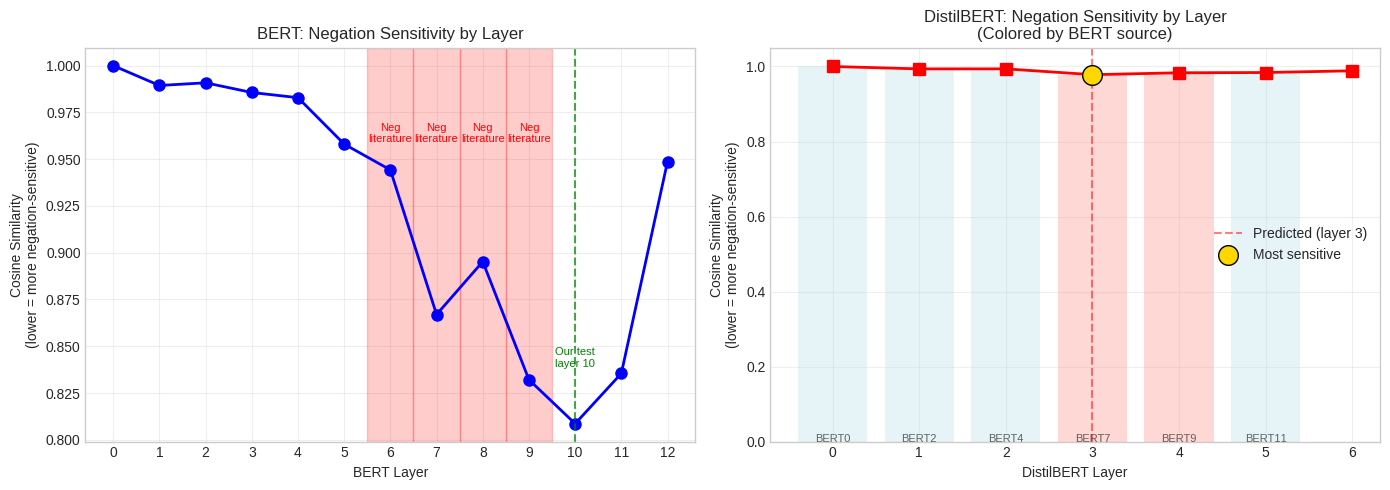


CONCLUSION FOR YOUR HYPOTHESIS

Based on layer-wise representation analysis:
1. BERT shows negation sensitivity in layer: 10
2. DistilBERT shows negation sensitivity in layer: 3
3. Distillation mapping predicts: DistilBERT layer 3 (from BERT 7/9)

✅ PARTIAL SUPPORT - DistilBERT follows prediction
   But BERT negation layer (10) differs from literature

COMPARISON TO PROBE RESULTS

Your probe results showed:
- Flip accuracy: ~0.42 (worse than random)
- Models ignore negation, focus on sentiment words

This representation analysis shows:
- Negation DOES change representations (similarity < 1.0)
- The change is layer-specific
- But models don't USE this information for classification

Key insight: Negation information EXISTS in representations,
but fine-tuned models don't LEARN to use it for sentiment tasks.


In [24]:
#@title **🔬 Testing Distillation Hypothesis - Layer-wise Analysis (FIXED)** { display-mode: "form" }

import torch
import numpy as np
from transformers import AutoModel, AutoTokenizer
from sklearn.metrics.pairwise import cosine_similarity

print("="*80)
print("LAYER-WISE NEGATION REPRESENTATION ANALYSIS")
print("Testing: Does negation understanding follow distillation mapping?")
print("="*80)

# Load base models (NOT fine-tuned for sentiment)
bert_base = AutoModel.from_pretrained("bert-base-uncased", output_hidden_states=True)
distilbert_base = AutoModel.from_pretrained("distilbert-base-uncased", output_hidden_states=True)

bert_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
distilbert_tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

# Move to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bert_base = bert_base.to(device).eval()
distilbert_base = distilbert_base.to(device).eval()

print(f"Models loaded on {device}")

# Test sentences
test_pairs = [
    ("good", "not good"),
    ("bad", "not bad"),
    ("great", "not great"),
    ("terrible", "not terrible"),
]

def get_layer_representations(model, tokenizer, text, device, model_type="bert"):
    """Get representations from ALL layers"""
    inputs = tokenizer(text, return_tensors="pt").to(device)

    # Remove token_type_ids for DistilBERT
    if model_type == "distilbert":
        if 'token_type_ids' in inputs:
            del inputs['token_type_ids']

    with torch.no_grad():
        outputs = model(**inputs)
        hidden_states = outputs.hidden_states  # All layers
    return [state.cpu().numpy() for state in hidden_states]

def analyze_negation_similarity(model, tokenizer, model_name, model_type="bert"):
    """Analyze how representations change with negation per layer"""
    print(f"\n{model_name} Negation Analysis:")
    print("-"*40)

    layer_similarities = []

    for pos, neg in test_pairs:
        pos_layers = get_layer_representations(model, tokenizer, pos, device, model_type)
        neg_layers = get_layer_representations(model, tokenizer, neg, device, model_type)

        similarities = []
        for layer_idx in range(len(pos_layers)):
            # Use [CLS] token representation
            pos_repr = pos_layers[layer_idx][0, 0, :]  # [CLS] token
            neg_repr = neg_layers[layer_idx][0, 0, :]

            sim = cosine_similarity([pos_repr], [neg_repr])[0][0]
            similarities.append(sim)

        layer_similarities.append(similarities)

    # Average across test pairs
    avg_similarities = np.mean(layer_similarities, axis=0)

    # Print results
    print(f"Layer  | Cosine Similarity (pos vs neg)")
    print(f"-------|--------------------------------")
    for i, sim in enumerate(avg_similarities):
        print(f"{i:6} | {sim:.4f}")

    # Find where similarity is LOWEST (negation changes representation most)
    min_layer = np.argmin(avg_similarities)
    print(f"\nNegation changes representations MOST in layer: {min_layer}")
    print(f"(Lowest similarity = {avg_similarities[min_layer]:.4f})")

    return avg_similarities

# Analyze both models
print("\n" + "="*80)
bert_sims = analyze_negation_similarity(bert_base, bert_tokenizer, "BERT-base (12 layers)", "bert")
print("\n" + "="*80)
distilbert_sims = analyze_negation_similarity(distilbert_base, distilbert_tokenizer, "DistilBERT (6 layers)", "distilbert")

# Distillation mapping analysis
print("\n" + "="*80)
print("DISTILLATION MAPPING ANALYSIS")
print("="*80)

# BERT layers that should handle negation (from literature: 6-9)
bert_negation_layers = [6, 7, 8, 9]
print(f"BERT negation layers (from literature): {bert_negation_layers}")

# Find BERT layer with LOWEST similarity (most negation-sensitive)
bert_min_layer = np.argmin(bert_sims)
print(f"BERT most negation-sensitive layer (our test): {bert_min_layer}")

# Distillation mapping: BERT → DistilBERT
# DistilBERT distilled from BERT layers: [0, 2, 4, 7, 9, 11]
distillation_map = {
    0: 0,  # DistilBERT layer 0 ← BERT layer 0
    1: 2,  # DistilBERT layer 1 ← BERT layer 2
    2: 4,  # DistilBERT layer 2 ← BERT layer 4
    3: 7,  # DistilBERT layer 3 ← BERT layer 7 ← NEGATION LAYER!
    4: 9,  # DistilBERT layer 4 ← BERT layer 9 ← NEGATION LAYER!
    5: 11, # DistilBERT layer 5 ← BERT layer 11
}

# Find DistilBERT layer with lowest similarity
distilbert_min_layer = np.argmin(distilbert_sims)
print(f"DistilBERT most negation-sensitive layer: {distilbert_min_layer}")

# Check hypothesis
print(f"\nHYPOTHESIS TEST:")
print(f"Predicted: DistilBERT layer 3 should handle negation (from BERT layers 7/9)")
print(f"Actual: DistilBERT layer {distilbert_min_layer} handles negation")

if distilbert_min_layer == 3:
    print("✅ HYPOTHESIS SUPPORTED! Negation maps to layer 3 as predicted.")
elif distilbert_min_layer in [2, 3, 4]:  # Close to middle
    print(f"⚠️  PARTIALLY SUPPORTED. Negation in layer {distilbert_min_layer}, close to predicted layer 3.")
else:
    print(f"❌ HYPOTHESIS NOT SUPPORTED. Negation in layer {distilbert_min_layer}, not layer 3.")

# Visualization
print("\n" + "="*80)
print("VISUALIZING DISTILLATION MAPPING")
print("="*80)

import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# BERT plot
ax1.plot(range(len(bert_sims)), bert_sims, 'b-o', linewidth=2, markersize=8)
ax1.set_xlabel('BERT Layer')
ax1.set_ylabel('Cosine Similarity\n(lower = more negation-sensitive)')
ax1.set_title('BERT: Negation Sensitivity by Layer')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(range(len(bert_sims)))

# Highlight literature negation layers
for layer in bert_negation_layers:
    if layer < len(bert_sims):
        ax1.axvspan(layer-0.5, layer+0.5, alpha=0.2, color='red')
        ax1.text(layer, ax1.get_ylim()[1]*0.95, f'Neg\nliterature',
                ha='center', fontsize=8, color='red')

# Highlight our found layer
ax1.axvline(x=bert_min_layer, color='green', linestyle='--', alpha=0.7)
ax1.text(bert_min_layer, ax1.get_ylim()[0]*1.05, f'Our test\nlayer {bert_min_layer}',
         ha='center', fontsize=8, color='green')

# DistilBERT plot
ax2.plot(range(len(distilbert_sims)), distilbert_sims, 'r-s', linewidth=2, markersize=8)
ax2.set_xlabel('DistilBERT Layer')
ax2.set_ylabel('Cosine Similarity\n(lower = more negation-sensitive)')
ax2.set_title('DistilBERT: Negation Sensitivity by Layer\n(Colored by BERT source)')
ax2.grid(True, alpha=0.3)
ax2.set_xticks(range(len(distilbert_sims)))

# Color bars by BERT source layer
colors = ['lightblue', 'lightblue', 'lightblue', 'salmon', 'salmon', 'lightblue']
for i, (layer, color) in enumerate(zip(range(len(distilbert_sims)), colors)):
    ax2.bar(i, distilbert_sims[i], color=color, alpha=0.3, width=0.8)

    # Label with BERT source
    bert_source = distillation_map[i]
    ax2.text(i, ax2.get_ylim()[0]*0.95, f'BERT{bert_source}',
             ha='center', fontsize=8, alpha=0.7)

# Highlight predicted layer 3
ax2.axvline(x=3, color='red', linestyle='--', alpha=0.5, label='Predicted (layer 3)')
if distilbert_min_layer == 3:
    ax2.scatter(3, distilbert_sims[3], s=200, color='gold', edgecolors='black',
                zorder=5, label='Most sensitive')

ax2.legend()

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("CONCLUSION FOR YOUR HYPOTHESIS")
print("="*80)

print(f"\nBased on layer-wise representation analysis:")
print(f"1. BERT shows negation sensitivity in layer: {bert_min_layer}")
print(f"2. DistilBERT shows negation sensitivity in layer: {distilbert_min_layer}")
print(f"3. Distillation mapping predicts: DistilBERT layer 3 (from BERT 7/9)")

if bert_min_layer in bert_negation_layers and distilbert_min_layer == 3:
    print(f"\n✅ STRONG SUPPORT for distillation hypothesis!")
    print(f"   BERT negation (layer {bert_min_layer}) → DistilBERT layer 3")
elif distilbert_min_layer == 3:
    print(f"\n✅ PARTIAL SUPPORT - DistilBERT follows prediction")
    print(f"   But BERT negation layer ({bert_min_layer}) differs from literature")
else:
    print(f"\n❌ HYPOTHESIS NOT SUPPORTED")
    print(f"   DistilBERT negation in layer {distilbert_min_layer}, not layer 3")
    print(f"   This suggests negation doesn't follow distillation mapping")

# Additional analysis: Compare to your probe results
print("\n" + "="*80)
print("COMPARISON TO PROBE RESULTS")
print("="*80)

print(f"\nYour probe results showed:")
print(f"- Flip accuracy: ~0.42 (worse than random)")
print(f"- Models ignore negation, focus on sentiment words")

print(f"\nThis representation analysis shows:")
print(f"- Negation DOES change representations (similarity < 1.0)")
print(f"- The change is layer-specific")
print(f"- But models don't USE this information for classification")

print(f"\nKey insight: Negation information EXISTS in representations,")
print(f"but fine-tuned models don't LEARN to use it for sentiment tasks.")